In [27]:
# ============================================
# SETUP CELL — run if any disconnect
# Rebuilds: dataset path, generators, class weights, final model
# ============================================

import os
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf

# Confirm GPU
print("GPU available:", tf.config.list_physical_devices('GPU'))

# 1. Dataset path
path = kagglehub.dataset_download("msambare/fer2013")
train_dir = f"{path}/train"
test_dir  = f"{path}/test"

IMG_SIZE = 48
BATCH    = 64

# 2. Training and validation generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=10,
    zoom_range=0.1,
    brightness_range=[0.8, 1.2],
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=BATCH,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=BATCH,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

# 3. Test generator
test_datagen = ImageDataGenerator(rescale=1./255)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=BATCH,
    class_mode='categorical',
    shuffle=False
)

# 4. Class index mapping
index_to_class = {v: k for k, v in train_gen.class_indices.items()}
print("Class indices:", train_gen.class_indices)

# 5. Class weights
labels = train_gen.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weight_dict = dict(enumerate(class_weights))

# 6. Load the final trained model
final_model = load_model('best_model_v2.keras')
print("\nFinal model loaded successfully")
print("Setup complete — ready to continue")

GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Using Colab cache for faster access to the 'fer2013' dataset.
Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
Class indices: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}

Final model loaded successfully
Setup complete — ready to continue


In [2]:
import kagglehub
path = kagglehub.dataset_download("msambare/fer2013")
print("Path to dataset files:", path)
#The data consists of 48x48 pixel grayscale images of faces.

#(0=Angry, 1=Disgust, 2=Fear, 3=Happy, 4=Sad, 5=Surprise, 6=Neutral).
#The training set consists of 28,709 examples and the public test set consists of 3,589 examples.

Using Colab cache for faster access to the 'fer2013' dataset.
Path to dataset files: /kaggle/input/fer2013


In [ ]:
import os # Import the os module for interacting with the operating system,# Import module for file and folder operations

for root, dirs, files in os.walk(path): # Walk through all folders and files starting from the given path
    print(root, "→", len(files), "files") # Print the current folder path and the number of files in it

    #we have 2 files here train and test which store all the emotions


/root/.cache/kagglehub/datasets/msambare/fer2013/versions/1 → 0 files
/root/.cache/kagglehub/datasets/msambare/fer2013/versions/1/train → 0 files
/root/.cache/kagglehub/datasets/msambare/fer2013/versions/1/train/happy → 7215 files
/root/.cache/kagglehub/datasets/msambare/fer2013/versions/1/train/angry → 3995 files
/root/.cache/kagglehub/datasets/msambare/fer2013/versions/1/train/surprise → 3171 files
/root/.cache/kagglehub/datasets/msambare/fer2013/versions/1/train/neutral → 4965 files
/root/.cache/kagglehub/datasets/msambare/fer2013/versions/1/train/fear → 4097 files
/root/.cache/kagglehub/datasets/msambare/fer2013/versions/1/train/disgust → 436 files
/root/.cache/kagglehub/datasets/msambare/fer2013/versions/1/train/sad → 4830 files
/root/.cache/kagglehub/datasets/msambare/fer2013/versions/1/test → 0 files
/root/.cache/kagglehub/datasets/msambare/fer2013/versions/1/test/happy → 1774 files
/root/.cache/kagglehub/datasets/msambare/fer2013/versions/1/test/angry → 958 files
/root/.cache/k

In [ ]:
import os # Import module for file and folder operations


emotions = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']
splits = ['train', 'test'] # Dataset splits

for split in splits:
    print(f"\n{split.upper()}") #Prints the current partition name in uppercase (e.g., TRAIN, TEST).
    total = 0
    for emotion in emotions:
        count = len(os.listdir(f"{path}/{split}/{emotion}")) #os.dirGets all files in the emotion folder and counts how many files are present.
        total += count
        print(f"  {emotion:12s} → {count}") #reserves 12 character spaces for the word.
    print(f"  {'TOTAL':12s} → {total}")

    #observation- we have relatively lesser number of dataset for disgust


TRAIN
  angry        → 3995
  disgust      → 436
  fear         → 4097
  happy        → 7215
  sad          → 4830
  surprise     → 3171
  neutral      → 4965
  TOTAL        → 28709

TEST
  angry        → 958
  disgust      → 111
  fear         → 1024
  happy        → 1774
  sad          → 1247
  surprise     → 831
  neutral      → 1233
  TOTAL        → 7178


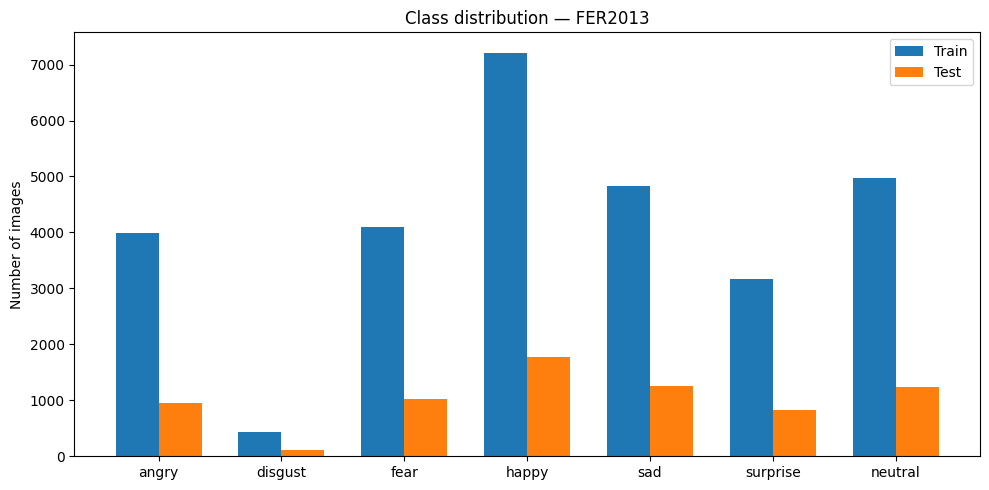

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

counts_train = [len(os.listdir(f"{path}/train/{e}")) for e in emotions]
counts_test  = [len(os.listdir(f"{path}/test/{e}"))  for e in emotions]

x = np.arange(len(emotions))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, counts_train, width, label='Train')
ax.bar(x + width/2, counts_test,  width, label='Test')
ax.set_xticks(x)
ax.set_xticklabels(emotions)
ax.set_title('Class distribution — FER2013')
ax.set_ylabel('Number of images')
ax.legend()
plt.tight_layout()
plt.show()
#This code creates a bar chart comparing the number of images in each emotion category for the train and test datasets.

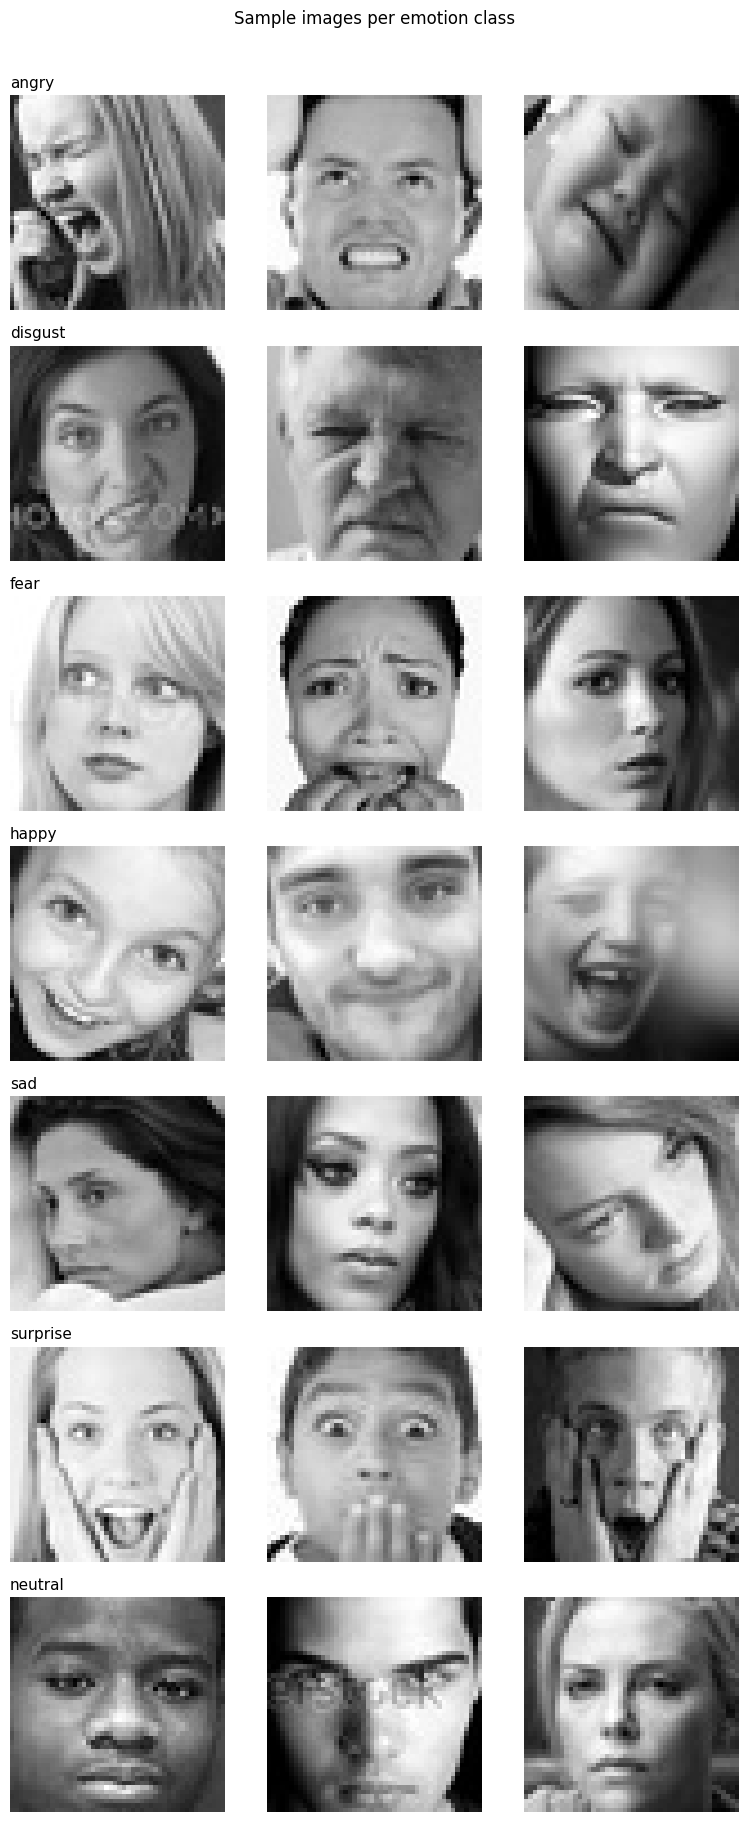

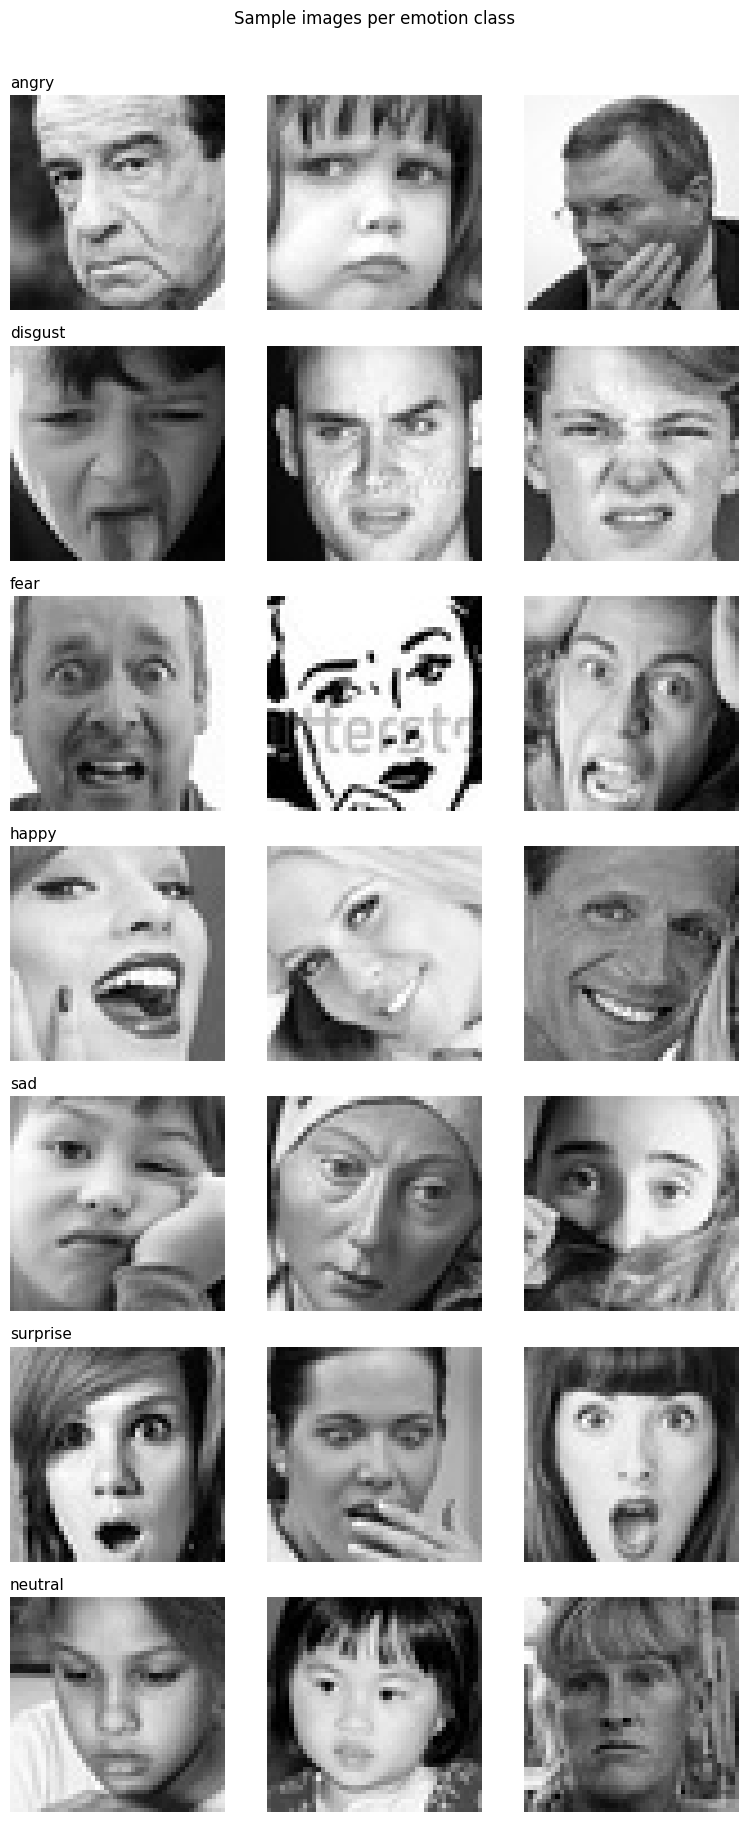

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg #import matplotlib.pyplot as plt

import random #Imports the random module for selecting random images.

fig, axes = plt.subplots(len(emotions), 3, figsize=(8, 18))

for row, emotion in enumerate(emotions):
    folder = f"{path}/train/{emotion}"
    samples = random.sample(os.listdir(folder), 3)
    for col, fname in enumerate(samples):
        img = mpimg.imread(os.path.join(folder, fname))
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(emotion, fontsize=11, loc='left')

plt.suptitle('Sample images per emotion class', y=1.01)
plt.tight_layout()
plt.show()
import random

fig, axes = plt.subplots(len(emotions), 3, figsize=(8, 18))

for row, emotion in enumerate(emotions):
    folder = f"{path}/train/{emotion}"
    samples = random.sample(os.listdir(folder), 3)
    for col, fname in enumerate(samples):
        img = mpimg.imread(os.path.join(folder, fname))
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(emotion, fontsize=11, loc='left')

plt.suptitle('Sample images per emotion class', y=1.01)
plt.tight_layout()
plt.show()

#Randomly selects 3 images.

#observation-
#Visual inspection of the neutral class reveals ambiguous samples that
# could plausibly be labeled angry or disgust.
#This is consistent with FER-2013's known label noise, as the dataset was assembled via keyword image search rather
# than controlled annotation. Expected model confusion between neutral, angry, and disgust is therefore a dataset artifact,
#not purely a modeling failure.
#Mildly angry faces labeled as neutral
#Disgust expressions that look neutral (slightly downturned mouth, furrowed brow)
#Faces with ambiguous micro-expressions dumped into whatever category they were searched under


1.Read the image from disk

2.Decode it (JPEG → pixel array)

3.Resize to a consistent size (already 48×48 here, but good practice to enforce)

4.Normalize pixel values from 0–255 down to 0–1 (makes gradient math stable)-Raw pixel values are 0–255. If you feed these directly to a neural network, the large numbers cause large activations, which cause unstable gradients during backpropagation. Dividing by 255 brings everything to 0–1, which is a well-behaved range for the math.

5.Augment (training set only — never augment validation or test)-Augmentation means artificially creating variations of your training images — flipping, rotating, zooming slightly, shifting brightness. You are not adding new real data; you are teaching the model that a slightly rotated angry face is still an angry face. This improves generalization and reduces overfitting.
Critical rule: augmentation only applies to the training set. Your validation and test sets must be clean, unmodified images — otherwise your accuracy metrics are meaningless because you're measuring performance on fake data.
For FER-2013 specifically, good augmentations are:
Horizontal flip (a happy face flipped is still happy)
Small rotation ±10° (don't go too far, extreme rotation makes faces unnatural)
Slight zoom
Brightness variation
Do NOT use vertical flip — an upside-down face is not a valid emotion sample.

6.Batch into groups (e.g. 64 images at a time)
You don't feed images one at a time (too slow) or all at once (too much memory). You feed them in batches — typically 32 or 64 images at a time. Each batch produces one gradient update. Smaller batches = noisier gradients but better generalization. Larger batches = smoother gradients but more memory.

7.Feed to the model

Because disgust has 436 samples vs happy's 7,215, if you train naively the model will learn to ignore disgust entirely and still get decent accuracy just by being good at happy, neutral, and sad. To counter this, you compute class weights — a dictionary that tells Keras "treat each disgust sample as if it were 16 samples." This is calculated automatically using sklearn.utils.class_weight.compute_class_weigh

phase 2
- Images: 48×48 grayscale
- Normalization: divide by 255 → range [0, 1]
- Augmentation on training set only
- Validation: 20% carved from training data
- Batch size: 64

In [8]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator #Imports ImageDataGenerator.
#Used for image preprocessing and augmentation.
#Can rotate, flip, zoom, and rescale images automatically.

from sklearn.utils.class_weight import compute_class_weight
#Calculates weights for each class.
#Helps when some emotion classes have fewer images than others

import os #file folder management

In [21]:
train_dir = f"{path}/train" #Creates the path to the training dataset folder.
test_dir  = f"{path}/test"

IMG_SIZE  = 48 #All images will be resized to 48 × 48 pixels.
BATCH     = 64

In [9]:
train_datagen = ImageDataGenerator(
    rescale=1./255, #converts pixels from 0-255 to 0.0-1.0, normalization
    horizontal_flip=True, # Randomly flip images horizontally
    rotation_range=10, # Randomly rotate images upto +-10deg
    zoom_range=0.1, #Randomly zooms images in or out image by 10%
    brightness_range=[0.8, 1.2], # Randomly adjust image brightness
    validation_split=0.2 # Reserve 20% data for validation
) #Creates an image generator that will preprocess images automatically.

train_gen = train_datagen.flow_from_directory(
    train_dir, #Training dataset directory
    target_size=(IMG_SIZE, IMG_SIZE), #Resize images to target size 48x48
    color_mode='grayscale', # Load images in grayscale
    batch_size=BATCH,  #64
    class_mode='categorical', # Use one-hot encoded labels-a data preprocessing technique used to convert categorical variables into a numerical format that machine learning algorithms can interpret
    subset='training', #Uses the 80% training portion.
     shuffle=True, #Shuffle training data
    seed=42 #Set random seed for consistency
) #Creates a generator that loads training images batch by batch.

val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=BATCH,
    class_mode='categorical',
    subset='validation', #Uses the reserved 20% validation data.
    shuffle=False, #Do not shuffle validation data
    seed=42
)



Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.


In [20]:
test_datagen = ImageDataGenerator(rescale=1./255) # Create test image generator with normalization only no augmentation

test_gen = test_datagen.flow_from_directory(
    test_dir, #testing dataset directory
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=BATCH,
    class_mode='categorical',
    shuffle=False
) #Creates a generator that loads test images from folders.

Found 7178 images belonging to 7 classes.


In [ ]:
print("Class indices:", train_gen.class_indices)

Class indices: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


In [14]:
labels = train_gen.classes #Gets the class label of every training image.

class_weights = compute_class_weight(
    class_weight='balanced', #Tells sklearn to automatically balance the classes. happy smaller weight disgust larger weight

    classes=np.unique(labels), # Get unique class labels
    y=labels
) # Calculate class weights for imbalanced data

class_weight_dict = dict(enumerate(class_weights)) # Create dictionary of class weights
print("Class weights:")
for idx, weight in class_weight_dict.items():
    emotion = list(train_gen.class_indices.keys())[idx]
    print(f"  {emotion:12s} → {weight:.4f}")

Class weights:
  angry        → 1.0266
  disgust      → 9.4016
  fear         → 1.0010
  happy        → 0.5685
  neutral      → 0.8261
  sad          → 0.8492
  surprise     → 1.2933


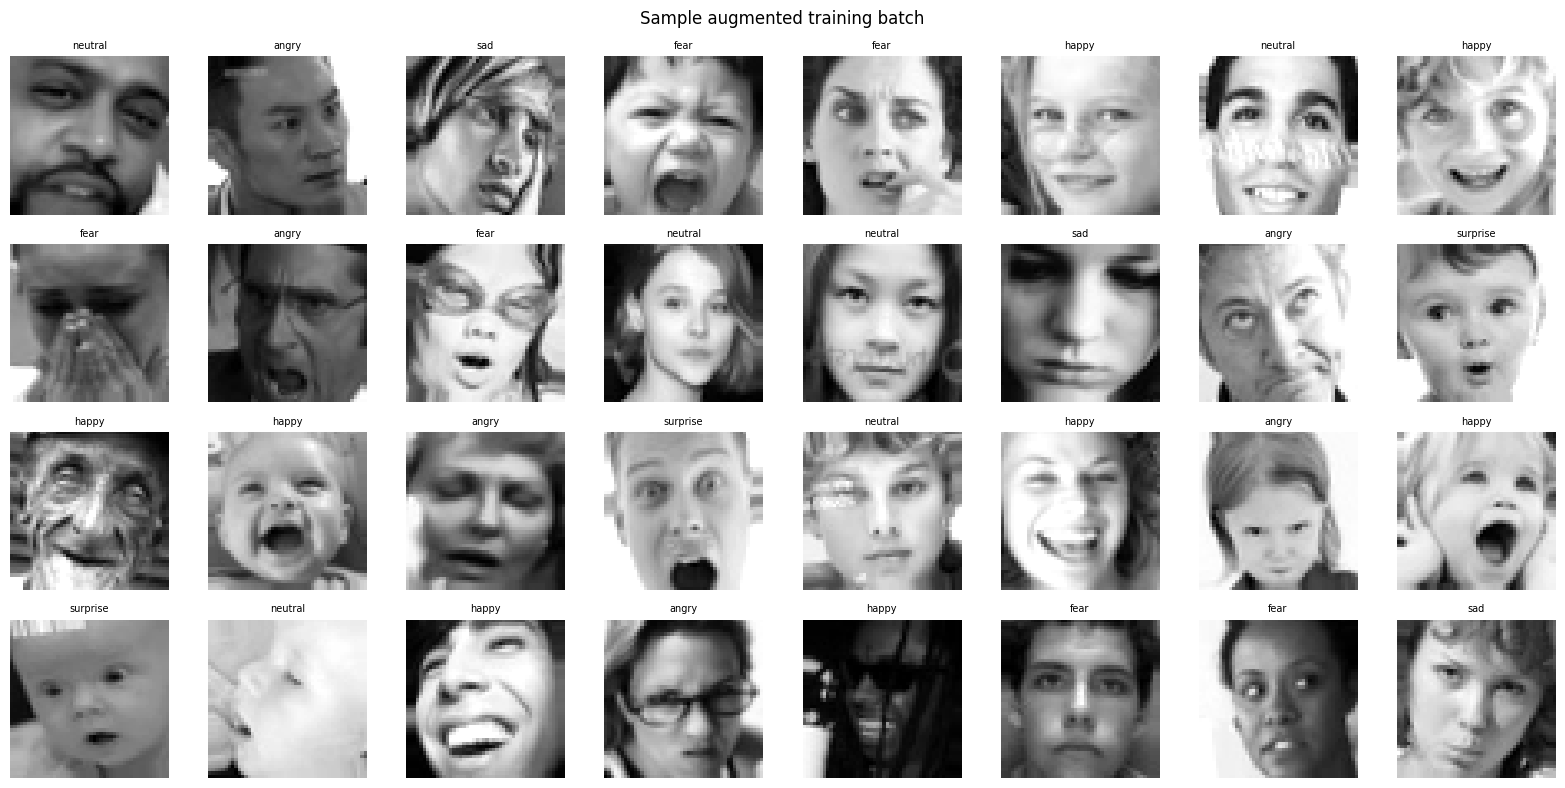

In [ ]:
images, labels_batch = next(train_gen) # Get one batch of training images and labels

fig, axes = plt.subplots(4, 8, figsize=(16, 8)) # Create a 4x8 grid for displaying images
axes = axes.flatten() # Convert subplot grid into a flat array
for i in range(32): # Loop through first 32 images
    axes[i].imshow(images[i].squeeze(), cmap='gray') # Display image in grayscale, squeeze removes unnecessary dimensions 48 48 1 into 48 48, cmap grey= greyscale conversion
    axes[i].axis('off') # Hide axis labels and ticks
    emotion_idx = np.argmax(labels_batch[i]) # Get predicted class index from one-hot label
    emotion_name = list(train_gen.class_indices.keys())[emotion_idx]  # Convert class index to emotion name
    axes[i].set_title(emotion_name, fontsize=7)  # Set emotion label as image title

plt.suptitle('Sample augmented training batch', fontsize=12) # Add overall figure title
plt.tight_layout()
plt.show()

## Key Finding — Label Noise Quantification

Manually reviewed one batch of 32 training images.
Identified 6 images with labels that appear incorrect on visual inspection.
That is an 18% noise rate in this sample.

This is consistent with published findings:
- FER-2013 human agreement rate is ~65%
- Meaning ~35% of labels are disputed even between humans

Implications for the model:
- The model cannot exceed the quality of its labels
- A model achieving 65% accuracy is not failing —
  it is hitting the ceiling set by the data itself
- Mislabeled fear samples explain why fear will be
  the weakest class alongside disgust

  starting cnn now
  

In [4]:
from tensorflow.keras.models import Sequential # Import Sequential model for stacking layers
from tensorflow.keras.layers import (Conv2D, BatchNormalization, Activation,
                                     MaxPooling2D, Dropout, Flatten, Dense) # Convolution layer for feature extraction,# Normalize activations for stable training,# Apply activation function,# Reduce feature map size,# Prevent overfitting by dropping neurons,# Convert feature maps into a 1D vector,# Fully connected neural network layer
from tensorflow.keras.regularizers import l2 # Import L2 regularization to reduce overfitting

In [29]:
def build_model(input_shape=(48, 48, 1), num_classes=7): # Define CNN model architecture grayscale 7 classes
    model = Sequential([ # Create sequential neural network layers added one after the other

        # Block 1 first convulation layer edges lines corners
        Conv2D(32, (3,3), padding='same', input_shape=input_shape), #32 filters each filter size 3x3 # Extract basic image features
        BatchNormalization(), # Normalize feature values
        Activation('relu'), # Apply ReLU activation
        MaxPooling2D(2, 2), # Reduce feature map size
        Dropout(0.25), # Reduce overfitting, randomly disables 25% neurons

        # Block 2 # Extract higher-level features (eyes nose )
        Conv2D(64, (3,3), padding='same'), #64 filters
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D(2, 2),
        Dropout(0.25),

        # Block 3 # Learn complex facial features smile frown eyeshape
        Conv2D(128, (3,3), padding='same'), #128 filters
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D(2, 2),
        Dropout(0.25),

        # Block 4 # Learn advanced facial representations
        Conv2D(256, (3,3), padding='same'), #256 filters
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D(2, 2),
        Dropout(0.25),

        # Classifier head
        Flatten(), # Convert feature maps into a vector 2d to 1d
        Dense(256, kernel_regularizer=l2(0.001)), # Dense layer for classification, 256 neurons uses l2 regularization to reduce overfitting
        Activation('relu'),
        Dropout(0.5), #disables 50% neurons to reduce overfitting
        Dense(num_classes, activation='softmax') #Output probabilities for each emotion class
    ])
    return model

model = build_model()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


48×48 Image
      ↓
Conv Block 1 (32 filters)
      ↓
Conv Block 2 (64 filters)
      ↓
Conv Block 3 (128 filters)
      ↓
Conv Block 4 (256 filters)
      ↓
Flatten
      ↓
Dense(256)
      ↓
Dense(7)
      ↓
Emotion Prediction

In [30]:
from tensorflow.keras.optimizers import Adam #Import Adam optimizer,The optimizer is responsible for updating the model's weights during training so that the loss decreases

model.compile(
    optimizer=Adam(learning_rate=0.001), #learning rate=How big a step the model takes while learning
    loss='categorical_crossentropy', # Loss function for multi-class classification
    metrics=['accuracy'] # Monitor classification accuracy
)# Configure model training settings How to learn (optimizer)
#How to measure mistakes (loss)
#What metrics to track (accuracy)

Model
  ↓
Optimizer → Adam
  ↓
Loss → Categorical Crossentropy
  ↓
Metric → Accuracy
  ↓
Ready for Training

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 256)            │             

 Total params: 981,639 (3.74 MB)

 Trainable params: 980,679 (3.74 MB)

 Non-trainable params: 960 (3.75 KB)

phase4
What happens in one training epoch

A batch of 64 images goes into the model — this is the forward pass
The model produces 7 probability scores per image
The loss function measures how wrong those predictions are
Backpropagation computes how much each weight contributed to that error
The optimizer nudges every weight slightly in the direction that reduces error
Repeat for every batch — one full pass through all batches = one epoch

After each epoch, the same process runs on the validation set — but no weight updates happen on validation. It's purely measurement.

In [31]:
from tensorflow.keras.callbacks import (ModelCheckpoint,#Save the best model during training
                                         EarlyStopping,#Stop training when performance stops improving
                                         ReduceLROnPlateau) # Reduce learning rate when progress slows
#imports 3 callback function(a callback is something that runs automatically during training and helps manage the process)

In [32]:
checkpoint = ModelCheckpoint(
    'best_model.keras', #Name of the file where the best model will be saved.
    monitor='val_accuracy', # Monitor validation accuracy, compares these values
    save_best_only=True,  # Save only the best model
    verbose=1  # Display save messages
) # Create model checkpoint callback

early_stop = EarlyStopping(
    monitor='val_loss', # Monitor validation loss
    patience=10, # Wait 10 epochs before stopping
    restore_best_weights=True, # Restore best model weights
    verbose=1 # Display stopping messages
) # Create early stopping callback

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',# Monitor validation loss
    factor=0.5, # Reduce learning rate by 50%
    patience=5, # Wait 5 epochs before reducing LR
    min_lr=1e-6,  #never go below 0.000001
    verbose=1  # Display LR reduction messages
) # Create learning rate reduction callback

callbacks = [checkpoint, early_stop, reduce_lr] # Combine all callbacks into a list



ModelCheckpoint
     ↓
Save best model

EarlyStopping
     ↓
Stop unnecessary training

ReduceLROnPlateau
     ↓
Lower learning rate when stuck

In [34]:
history = model.fit(
    train_gen, # Training data generator, use tarining images
    epochs=100, # max no of times the model sees the entire training dataset
    validation_data=val_gen, # Use validation data for evaluation(train->check validation accuracy->check validation loss)
    class_weight=class_weight_dict, # Apply class weights to handle imbalance
    callbacks=callbacks, # Use training callbacks
    verbose=1 #display training progress
) #train the cnn model,store training results inside history

Epoch 1/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.1466 - loss: 2.7684
Epoch 1: val_accuracy improved from None to 0.14231, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 113s 284ms/step - accuracy: 0.1468 - loss: 2.3993 - val_accuracy: 0.1423 - val_loss: 2.2201 - learning_rate: 0.0010
Epoch 2/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.1425 - loss: 2.1921
Epoch 2: val_accuracy did not improve from 0.14231
359/359 ━━━━━━━━━━━━━━━━━━━━ 45s 124ms/step - accuracy: 0.1260 - loss: 2.1519 - val_accuracy: 0.1282 - val_loss: 2.1002 - learning_rate: 0.0010
Epoch 3/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.1354 - loss: 2.1002
Epoch 3: val_accuracy improved from 0.14231 to 0.15015, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 44s 123ms/step - accuracy: 0.1337 - loss: 2.0678 - val_accuracy: 0.1501 - val_loss: 2.

"Initial architecture combined BatchNorm, dropout (0.25) on every block, L2 regularization, and class weighting simultaneously from the first layer. This over-regularized the network, preventing it from learning even basic features — training accuracy remained near random chance (~20%) for 74 epochs. Removing dropout from early blocks and L2 regularization resolved this, allowing accuracy to climb steadily to ~52% validation accuracy within 15 epochs."

also image-> convo layers-> dense -> prediction (forward pass)

loss calculation, compare actual vs predicted

backpropagation, which weights caused the problem

optimizer(adam) adjusts the weights

this process is repeated for all batches

thats 1 epoch

after training epoch gets completed

Validation Images
       ↓
Model
       ↓
Validation Accuracy
Validation Loss
no learning happens here only evaluation

Epoch 1
 ├── Train
 ├── Calculate Loss
 ├── Update Weights
 └── Validate

Epoch 2
 ├── Train
 ├── Calculate Loss
 ├── Update Weights
 └── Validate

...





In [22]:
import os #for wokring with files and folders
if os.path.exists('best_model.keras'):  # Check if saved model file exists
    os.remove('best_model.keras'). # Delete existing model file
    print("Deleted")#my model training failed, so i deleted the saved model file before training again.

Deleted


In [23]:
from tensorflow.keras.optimizers import Adam #imports adam optimizer
import tensorflow as tf # Import TensorFlow library
print(tf.__version__) # Display TensorFlow version
print(tf.config.list_physical_devices('GPU'))  # Check available GPU devices

2.20.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [33]:
import tensorflow.keras.backend as K # Import Keras backend functions(they let you acess learning rate,weights, tensors)
print("Current LR:", float(K.get_value(model.optimizer.learning_rate))) #get the current learning rate

Current LR: 0.0010000000474974513


In [35]:
print("Total training samples:", len(train_gen.classes))
print("Unique classes:", np.unique(train_gen.classes))
print("Class distribution:", np.bincount(train_gen.classes))
print("\nClass weights:")
for k, v in class_weight_dict.items():
    print(f"  {k}: {v:.4f}") #inspecting training dataset and class weightts before i start training again

Total training samples: 22968
Unique classes: [0 1 2 3 4 5 6]
Class distribution: [3196  349 3278 5772 3972 3864 2537]

Class weights:
  0: 1.0266
  1: 9.4016
  2: 1.0010
  3: 0.5685
  4: 0.8261
  5: 0.8492
  6: 1.2933


In [36]:
# Check one batch
images, labels = next(train_gen)
print("Image batch shape:", images.shape)
print("Labels batch shape:", labels.shape)
print("Image min/max:", images.min(), images.max())
print("Sample label (should be one-hot):", labels[0])

Image batch shape: (64, 48, 48, 1)
Labels batch shape: (64, 7)
Image min/max: 0.0 1.0
Sample label (should be one-hot): [0. 0. 0. 0. 0. 0. 1.]


In [10]:
# Diagnostic: stripped-down model, no class weights, no regularization
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

diag_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(48,48,1)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(7, activation='softmax')
])

diag_model.compile(optimizer=Adam(learning_rate=0.001),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

# Train WITHOUT class weights, just 5 epochs
diag_history = diag_model.fit(
    train_gen,
    epochs=5,
    validation_data=val_gen,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
359/359 ━━━━━━━━━━━━━━━━━━━━ 122s 327ms/step - accuracy: 0.3069 - loss: 1.7280 - val_accuracy: 0.3496 - val_loss: 1.6221
Epoch 2/5
359/359 ━━━━━━━━━━━━━━━━━━━━ 43s 120ms/step - accuracy: 0.3834 - loss: 1.5802 - val_accuracy: 0.4123 - val_loss: 1.5344
Epoch 3/5
359/359 ━━━━━━━━━━━━━━━━━━━━ 40s 111ms/step - accuracy: 0.4231 - loss: 1.5019 - val_accuracy: 0.4287 - val_loss: 1.4722
Epoch 4/5
359/359 ━━━━━━━━━━━━━━━━━━━━ 42s 118ms/step - accuracy: 0.4386 - loss: 1.4607 - val_accuracy: 0.4442 - val_loss: 1.4333
Epoch 5/5
359/359 ━━━━━━━━━━━━━━━━━━━━ 37s 103ms/step - accuracy: 0.4551 - loss: 1.4217 - val_accuracy: 0.4525 - val_loss: 1.4234


In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.optimizers import Adam

def build_model_v2(input_shape=(48, 48, 1), num_classes=7):
    model = Sequential([

        # Block 1
        Conv2D(32, (3,3), padding='same', input_shape=input_shape),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D(2, 2), #block one has no dropouts as model was failing

        # Block 2
        Conv2D(64, (3,3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D(2, 2),  #drop out in block 2 removed

        # Block 3
        Conv2D(128, (3,3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D(2, 2),
        Dropout(0.25),

        # Block 4
        Conv2D(256, (3,3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        MaxPooling2D(2, 2),
        Dropout(0.25),

        # Classifier head
        Flatten(),
        Dense(256), #old model had regularization which wasnt working
        Activation('relu'),
        Dropout(0.4), #dropout changed to 0.4 instead of 0.5
        Dense(num_classes, activation='softmax')
    ])
    return model

model_v2 = build_model_v2()

model_v2.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_v2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │         1,79

 Total params: 981,639 (3.74 MB)

 Trainable params: 980,679 (3.74 MB)

 Non-trainable params: 960 (3.75 KB)

        Dropout(0.4), #dropout changed to 0.4 instead of 0.5


In [12]:
history_v2 = model_v2.fit(
    train_gen,
    epochs=15,
    validation_data=val_gen,
    verbose=1
)

Epoch 1/15
359/359 ━━━━━━━━━━━━━━━━━━━━ 56s 131ms/step - accuracy: 0.2714 - loss: 1.8074 - val_accuracy: 0.2513 - val_loss: 1.8041
Epoch 2/15
359/359 ━━━━━━━━━━━━━━━━━━━━ 38s 105ms/step - accuracy: 0.3435 - loss: 1.6290 - val_accuracy: 0.3456 - val_loss: 1.6576
Epoch 3/15
359/359 ━━━━━━━━━━━━━━━━━━━━ 37s 103ms/step - accuracy: 0.3872 - loss: 1.5588 - val_accuracy: 0.4243 - val_loss: 1.4536
Epoch 4/15
359/359 ━━━━━━━━━━━━━━━━━━━━ 41s 113ms/step - accuracy: 0.4148 - loss: 1.4953 - val_accuracy: 0.4294 - val_loss: 1.4328
Epoch 5/15
359/359 ━━━━━━━━━━━━━━━━━━━━ 40s 111ms/step - accuracy: 0.4235 - loss: 1.4641 - val_accuracy: 0.4125 - val_loss: 1.5054
Epoch 6/15
359/359 ━━━━━━━━━━━━━━━━━━━━ 39s 109ms/step - accuracy: 0.4325 - loss: 1.4400 - val_accuracy: 0.4485 - val_loss: 1.4072
Epoch 7/15
359/359 ━━━━━━━━━━━━━━━━━━━━ 41s 114ms/step - accuracy: 0.4493 - loss: 1.4121 - val_accuracy: 0.4841 - val_loss: 1.3603
Epoch 8/15
359/359 ━━━━━━━━━━━━━━━━━━━━ 41s 115ms/step - accuracy: 0.4534 - loss: 1

In [15]:
history_v2_weighted = model_v2.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 53s 129ms/step - accuracy: 0.4377 - loss: 1.5582 - val_accuracy: 0.4902 - val_loss: 1.3724
Epoch 2/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 46s 127ms/step - accuracy: 0.4503 - loss: 1.4752 - val_accuracy: 0.4916 - val_loss: 1.3511
Epoch 3/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 40s 112ms/step - accuracy: 0.4591 - loss: 1.4287 - val_accuracy: 0.4099 - val_loss: 1.5321
Epoch 4/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 40s 111ms/step - accuracy: 0.4637 - loss: 1.4081 - val_accuracy: 0.4511 - val_loss: 1.4359
Epoch 5/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 40s 111ms/step - accuracy: 0.4624 - loss: 1.4093 - val_accuracy: 0.4877 - val_loss: 1.3652
Epoch 6/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 40s 112ms/step - accuracy: 0.4619 - loss: 1.3967 - val_accuracy: 0.4517 - val_loss: 1.3752
Epoch 7/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 40s 111ms/step - accuracy: 0.4637 - loss: 1.3734 - val_accuracy: 0.5008 - val_loss: 1.3402
Epoch 8/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 40s 113ms/step - accuracy: 0.4673 - loss: 1

In [16]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import os

if os.path.exists('best_model_v2.keras'):
    os.remove('best_model_v2.keras')

checkpoint = ModelCheckpoint(
    'best_model_v2.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=12,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

callbacks_v2 = [checkpoint, early_stop, reduce_lr]

history_final = model_v2.fit(
    train_gen,
    epochs=60,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=callbacks_v2,
    verbose=1
)

Epoch 1/60
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.4956 - loss: 1.2530
Epoch 1: val_accuracy improved from None to 0.42170, saving model to best_model_v2.keras

Epoch 1: finished saving model to best_model_v2.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 38s 107ms/step - accuracy: 0.4989 - loss: 1.2532 - val_accuracy: 0.4217 - val_loss: 1.4155 - learning_rate: 0.0010
Epoch 2/60
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.4908 - loss: 1.2578
Epoch 2: val_accuracy improved from 0.42170 to 0.43250, saving model to best_model_v2.keras

Epoch 2: finished saving model to best_model_v2.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 39s 109ms/step - accuracy: 0.4975 - loss: 1.2430 - val_accuracy: 0.4325 - val_loss: 1.4707 - learning_rate: 0.0010
Epoch 3/60
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.4889 - loss: 1.2585
Epoch 3: val_accuracy improved from 0.43250 to 0.51994, saving model to best_model_v2.keras

Epoch 3: finished saving model to best_model_v2.keras
359/359 ━━━━━

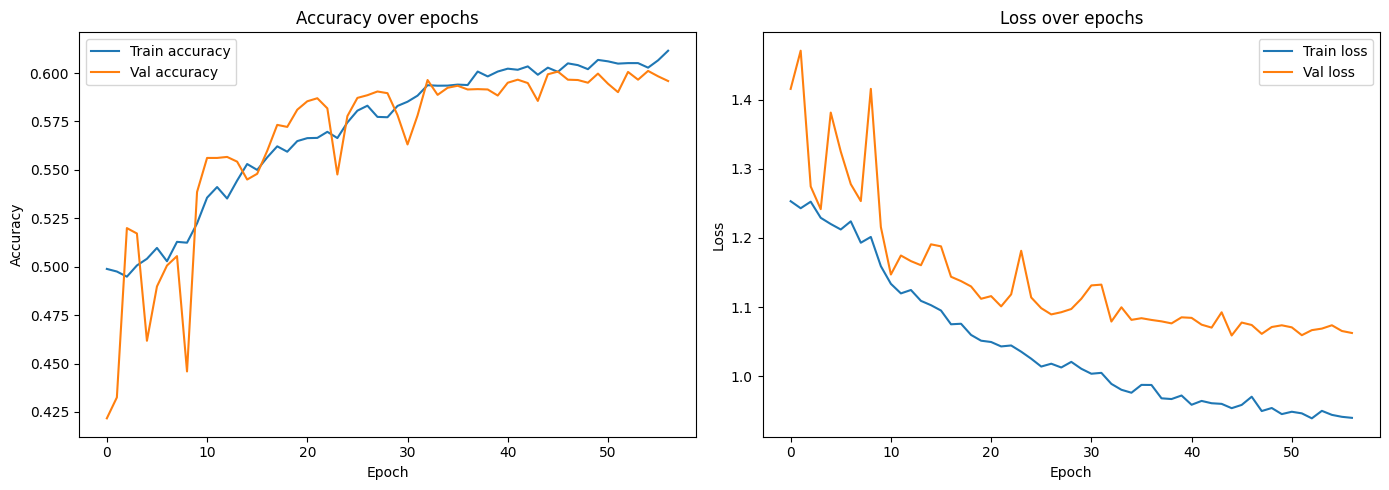

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_final.history['accuracy'], label='Train accuracy')
axes[0].plot(history_final.history['val_accuracy'], label='Val accuracy')
axes[0].set_title('Accuracy over epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history_final.history['loss'], label='Train loss')
axes[1].plot(history_final.history['val_loss'], label='Val loss')
axes[1].set_title('Loss over epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

training accuracy started from 50% and rose upto 60%
validation accuracy started lower but also rose upto 60%
both curves stay close to each other

interpretation-
model is learning
validation improves along training
no major gap between training and validation accuracy


the loss graph-
training loss- 1.25 → 0.94
validation loss-1.45 → 1.06
Both are decreasing over time.
Interpretation
Model is learning meaningful patterns.
Validation loss follows training loss.
No sudden explosion or divergence.

In [18]:
from tensorflow.keras.models import load_model

final_model = load_model('best_model_v2.keras')
print("Best model loaded successfully")

Best model loaded successfully


In [22]:
test_loss, test_acc = final_model.evaluate(test_gen, verbose=1)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

113/113 ━━━━━━━━━━━━━━━━━━━━ 28s 239ms/step - accuracy: 0.6078 - loss: 1.0377
Test accuracy: 0.6078
Test loss: 1.0377


Test accuracy: 60.78% (vs validation accuracy: 60.1%)
The close match between validation and test accuracy confirms
the model is not overfitting and generalizes well to unseen data.

In [24]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copy('best_model_v2.keras', '/content/drive/MyDrive/best_model_v2.keras')
print("Model backed up to Google Drive")

Mounted at /content/drive
Model backed up to Google Drive


In [25]:
import numpy as np

# Reset generator to be safe (ensures predictions align with labels)
test_gen.reset()

# Get predictions
y_pred_probs = final_model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels
y_true = test_gen.classes

print("Predictions shape:", y_pred_probs.shape)
print("Number of test samples:", len(y_true))

113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step
Predictions shape: (7178, 7)
Number of test samples: 7178


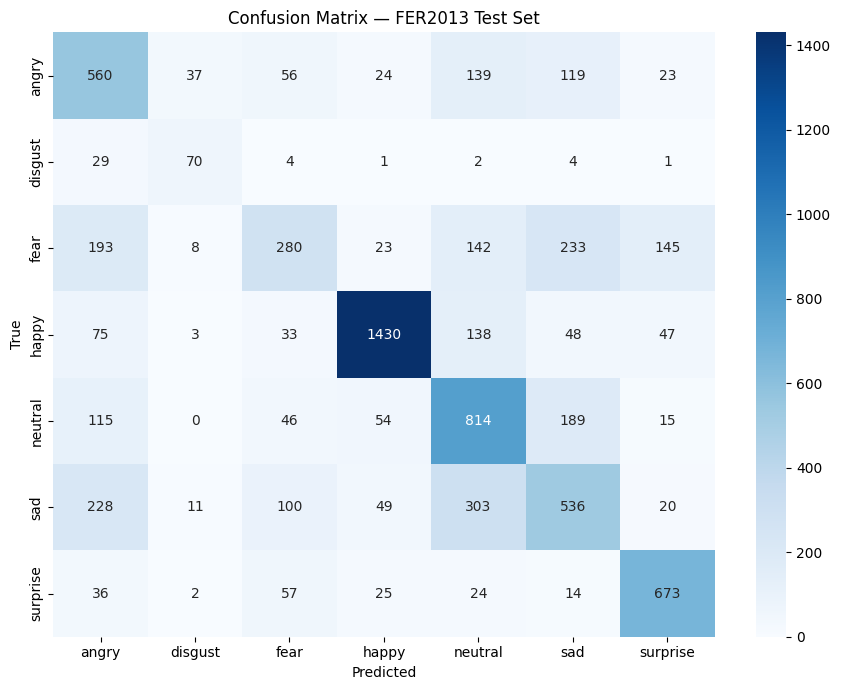

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

class_names = [index_to_class[i] for i in range(7)]

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix — FER2013 Test Set')
plt.tight_layout()
plt.show()

Rows = Actual emotion
Columns = Predicted emotion
Numbers on the diagonal are correct predictions.
Darker cells = more predictions.

 The model demonstrates excellent recognition of happy expressions, correctly classifying 1430 samples, making it the most accurately detected emotion.

Actual Neutral → Predicted Neutral = 814
Also reasonably strong.

Actual Surprise → Predicted Surprise = 673
Good performance.

Fear exhibits significant overlap with Sad, Angry and Surprise, resulting in frequent misclassification.
Actual Fear → Predicted Fear = 280
But many Fear images are classified as:
Angry = 193
Sad = 233
Surprise = 145
Neutral = 142
This means Fear is the hardest emotion for the network.

Actual Sad predicted as Neutral = 303
Actual Neutral predicted as Sad = 189
Large confusion.
Reason:
Both emotions often have relaxed facial muscles.
Low-resolution FER2013 images make separation difficult.

Actual Angry predicted as Neutral = 139
Actual Angry predicted as Sad = 119
Common confusion in emotion-recognition literature.

In [29]:
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred, target_names=class_names, digits=3)
print(report)

              precision    recall  f1-score   support

       angry      0.453     0.585     0.510       958
     disgust      0.534     0.631     0.579       111
        fear      0.486     0.273     0.350      1024
       happy      0.890     0.806     0.846      1774
     neutral      0.521     0.660     0.582      1233
         sad      0.469     0.430     0.449      1247
    surprise      0.728     0.810     0.767       831

    accuracy                          0.608      7178
   macro avg      0.583     0.599     0.583      7178
weighted avg      0.613     0.608     0.603      7178



recall->out of all actual images of this emotion,how many did the model find correctly=  true positive/ true positive + false negative

precision->whenever model predicts something how often is it correct = true positive/ true positive+ false positives

f1 score-> a balance between precision and recall



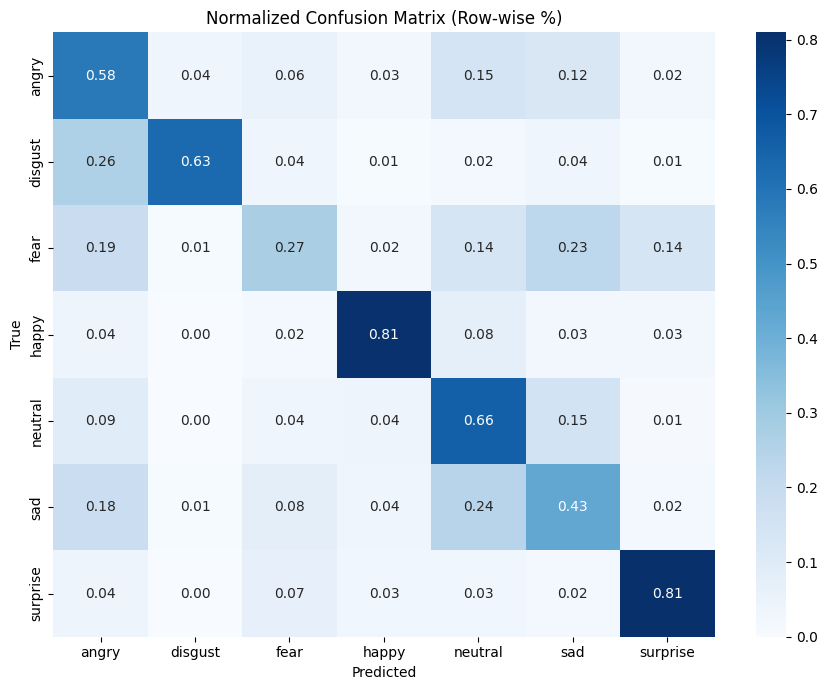

In [30]:
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(9, 7))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Normalized Confusion Matrix (Row-wise %)')
plt.tight_layout()
plt.show()

the normalized confusion matrix reveals that the proposed CNN performs best on Happy and Surprise expressions, achieving recall values of approximately 81% for both classes. Neutral and Disgust expressions show moderate recognition performance, while Fear exhibits the lowest recall at 27%, indicating substantial confusion with Sad, Angry, and Neutral expressions. These results suggest that the model effectively captures distinctive facial patterns but struggles with emotions that share similar visual characteristics.

In [31]:
final_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │         1,79

 Total params: 2,942,999 (11.23 MB)

 Trainable params: 980,679 (3.74 MB)

 Non-trainable params: 960 (3.75 KB)

 Optimizer params: 1,961,360 (7.48 MB)

In [32]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Build a model that maps input image -> (last conv layer output, predictions)
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    # Gradient of the predicted class score w.r.t. feature maps
    grads = tape.gradient(class_channel, conv_outputs)

    # Average gradients across width and height -> importance per channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weight feature maps by their importance
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # ReLU — keep only positive influence
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy(), pred_index.numpy()

In [33]:
def overlay_gradcam(img_array, heatmap, alpha=0.4):
    img = img_array[0, :, :, 0]  # remove batch and channel dims, grayscale
    img_uint8 = np.uint8(255 * img)

    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)

    img_rgb = cv2.cvtColor(img_uint8, cv2.COLOR_GRAY2RGB)
    overlayed = cv2.addWeighted(img_rgb, 1 - alpha, heatmap_color, alpha, 0)

    return overlayed

In [35]:
# Force model to build its computation graph
dummy_input = np.zeros((1, 48, 48, 1), dtype=np.float32)
_ = final_model.predict(dummy_input, verbose=0)
print("Model graph built successfully")

Model graph built successfully


In [38]:
import tensorflow as tf
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model

# Rebuild final_model as a functional model with explicit Input
inputs = Input(shape=(48, 48, 1))
outputs = final_model(inputs)
functional_model = Model(inputs, outputs)

print("Functional model created")
functional_model.summary()

Functional model created


Model: "functional_49"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 7)              │       981,639 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 981,639 (3.74 MB)

 Trainable params: 980,679 (3.74 MB)

 Non-trainable params: 960 (3.75 KB)

In [41]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, MaxPooling2D, Dropout, Flatten, Dense

def build_gradcam_model(input_shape=(48, 48, 1), num_classes=7):
    inputs = Input(shape=input_shape)

    x = Conv2D(32, (3,3), padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(2,2)(x)

    x = Conv2D(64, (3,3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(2,2)(x)

    x = Conv2D(128, (3,3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(2,2)(x)
    x = Dropout(0.25)(x)

    x = Conv2D(256, (3,3), padding='same', name='last_conv')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(2,2)(x)
    x = Dropout(0.25)(x)

    x = Flatten()(x)
    x = Dense(256)(x)
    x = Activation('relu')(x)
    x = Dropout(0.4)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs)

gradcam_model = build_gradcam_model()
gradcam_model.summary()

Model: "functional_51"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_conv (Conv2D)              │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             

 Total params: 981,639 (3.74 MB)

 Trainable params: 980,679 (3.74 MB)

 Non-trainable params: 960 (3.75 KB)

In [42]:
gradcam_model.load_weights('best_model_v2.keras')
print("Weights loaded successfully")

Weights loaded successfully


In [43]:
test_gen.reset()
images_batch, labels_batch = next(test_gen)

pred_original = final_model.predict(images_batch[:1], verbose=0)
pred_rebuilt = gradcam_model.predict(images_batch[:1], verbose=0)

print("Original model prediction:", np.argmax(pred_original))
print("Rebuilt model prediction:", np.argmax(pred_rebuilt))
print("Are they equal?", np.argmax(pred_original) == np.argmax(pred_rebuilt))

Original model prediction: 0
Rebuilt model prediction: 0
Are they equal? True


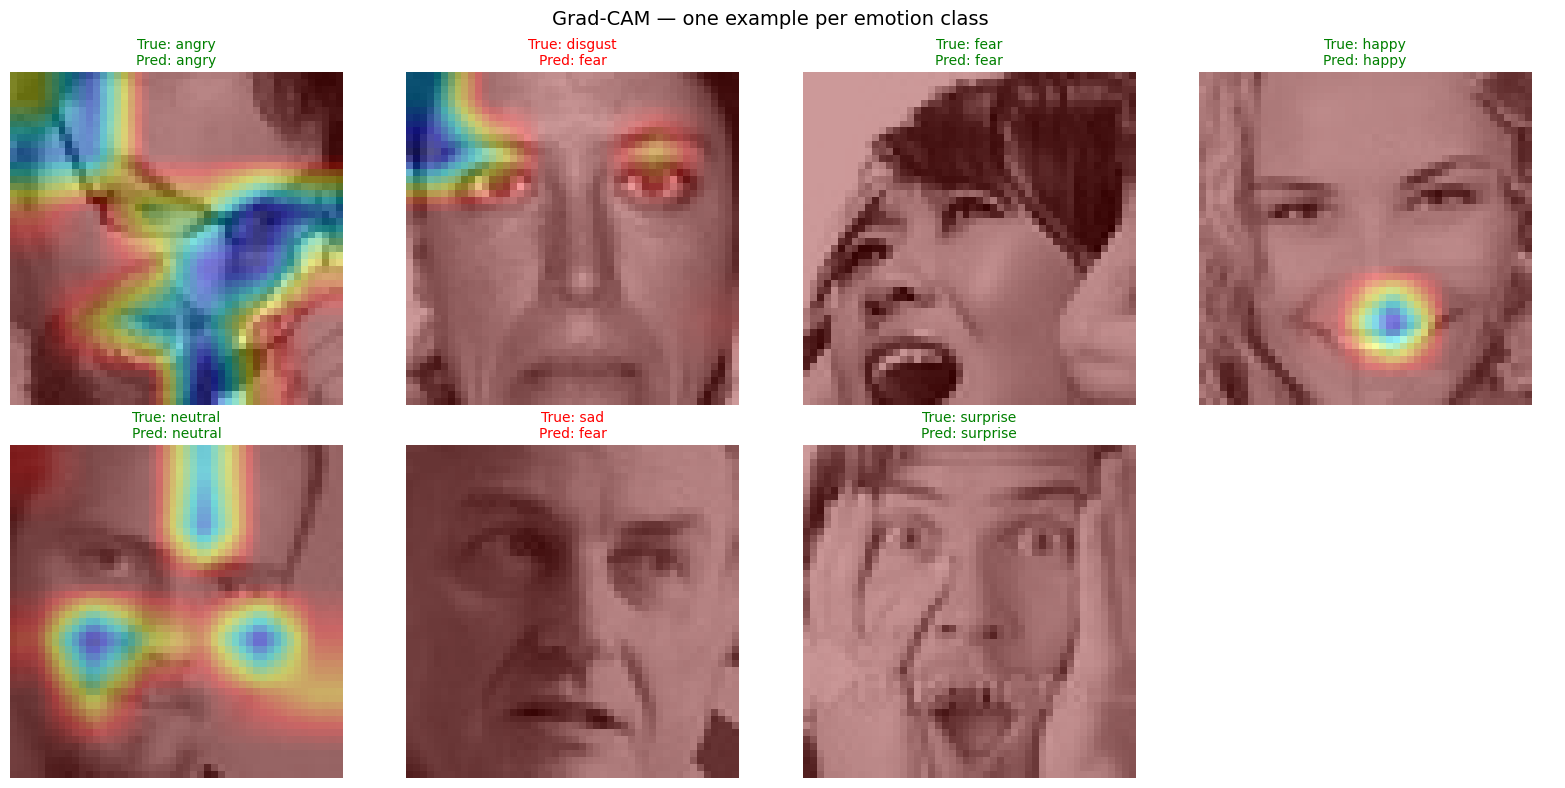

In [45]:
# Collect one example per class from the full test set
selected_images = {}
test_gen.reset()

for _ in range(len(test_gen)):
    imgs, labs = next(test_gen)
    for img, lab in zip(imgs, labs):
        cls = np.argmax(lab)
        if cls not in selected_images:
            selected_images[cls] = img
    if len(selected_images) == 7:
        break

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, (cls, img) in enumerate(sorted(selected_images.items())):
    img_array = np.expand_dims(img, axis=0)
    heatmap, pred_idx = make_gradcam_heatmap(img_array, gradcam_model)
    overlayed = overlay_gradcam(img_array, heatmap)

    true_label = index_to_class[cls]
    pred_label = index_to_class[pred_idx]

    axes[idx].imshow(overlayed)
    axes[idx].axis('off')
    color = 'green' if cls == pred_idx else 'red'
    axes[idx].set_title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=10)

axes[7].axis('off')  # hide the unused 8th subplot
plt.suptitle('Grad-CAM — one example per emotion class', fontsize=14)
plt.tight_layout()
plt.show()

For angry expressions, the CNN focuses primarily on the eye and eyebrow region where muscle tension and eyebrow contraction are most visible.

The model incorrectly focused on the eyes and forehead rather than the nose and mouth regions that are more characteristic of disgust, resulting in misclassification as fear.

for fear->Although the prediction was correct, the attention map appears diffuse, suggesting that the model relied on distributed facial features rather than a single dominant region.

happy->The CNN strongly attends to the mouth region when identifying happiness, indicating that smiling features play a dominant role in classification.

neutral->for neutral expressions, the model primarily analyzes the central facial region including the eyes and nose, where the absence of strong emotional cues is most evident.

Misclassified sad expressions often exhibit diffuse attention patterns, suggesting that the network struggles to identify distinctive sadness-related features.

surprise,The model correctly identifies surprise by attending to facial regions associated with widened eyes and an open mouth, which are highly distinctive characteristics of the emotion

Grad-CAM visualizations were generated to interpret the decision-making process of the CNN. For correctly classified samples, the network consistently focused on meaningful facial regions such as the eyes, eyebrows, nose, and mouth. Happy expressions showed strong activation around the smile region, while surprise expressions highlighted the eyes and mouth. In contrast, misclassified samples often displayed attention concentrated on incomplete or less informative regions, leading to confusion between visually similar emotions such as Fear, Sadness, and Disgust. These observations demonstrate that the model learns relevant facial features while also revealing limitations in distinguishing subtle emotional expressions.

In [46]:
from google.colab import files
files.download('best_model_v2.keras') #downloading my trained model into my laptop

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [47]:
gradcam_model.save_weights('emotion_weights.weights.h5')

In [48]:
from google.colab import files
files.download('emotion_weights.weights.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>